# CN Variable Analysis

**Two parts:**
1. Distribution statistics for all CN variables
2. Monthly mean maps (June / July / August) showing spatial cumulation of network patterns

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import xarray as xr

%matplotlib inline
plt.rcParams['figure.dpi'] = 120


In [3]:
DATA_FILE = "/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/full_processed_training_dataset.nc"
NUTS_FILE = "/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/NUTS_RG_01M_2024_4326_LEVL_2.geojson"
OUT_DIR   = "cn_analysis_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

CN_VARS = ["CC", "BC", "DC", "ID", "OD", "CC_target_next_day"]

CMAPS = {
    "CC":                 "YlOrRd",
    "BC":                 "PuRd",
    "DC":                 "Blues",
    "ID":                 "Greens",
    "OD":                 "Oranges",
    "CC_target_next_day": "YlOrRd",
}

MONTHS      = [6, 7, 8]
MONTH_NAMES = {6: "June", 7: "July", 8: "August"}


## Load Dataset

In [4]:
print("Loading dataset...")
ds    = xr.open_dataset(DATA_FILE)
lats  = ds["lat"].values
lons  = ds["lon"].values
times = pd.DatetimeIndex(ds["time"].values)

print(f"  Grid: {len(lats)} lat x {len(lons)} lon  |  {len(times)} timesteps")
print(f"  Period: {times[0].date()} to {times[-1].date()}")
print(f"  Variables: {list(ds.data_vars)}")

# Land mask (south-first)
land_mask_sf = ds["land_mask"].isel(time=0).values.astype(bool)

# North-first for plotting
lats_nf = lats[::-1]
LON2D, LAT2D = np.meshgrid(lons, lats_nf)
land_mask_nf  = land_mask_sf[::-1, :]

GEO_ASPECT = 1.0 / np.cos(np.radians((lats.min() + lats.max()) / 2))

def setup_ax(ax):
    ax.set_aspect(GEO_ASPECT)
    ax.set_xlim(lons.min(), lons.max())
    ax.set_ylim(lats.min(), lats.max())


Loading dataset...
  Grid: 141 lat x 264 lon  |  2667 timesteps
  Period: 1990-06-01 to 2020-08-30
  Variables: ['DC', 'CC', 'BC', 'ID', 'OD', 'is_heatwave', 'swvl1', 'land_mask', 'u', 'v', 'z', 'divergence', 'CC_target_next_day', 'event_label']


In [5]:
nuts    = gpd.read_file(NUTS_FILE).to_crs("EPSG:4326")
nuts_eu = nuts.cx[lons.min():lons.max(), lats.min():lats.max()]
print(f"  NUTS features: {len(nuts_eu)}")


  NUTS features: 286


---
## Part 1 — Distribution Statistics

For each CN variable: range, quantiles, zero-inflation, unique value count.  
Crucial for understanding whether regression makes sense and what threshold choices are appropriate.

In [6]:
stats_rows = []
dist_data  = {}

for var in CN_VARS:
    arr      = ds[var].values                     # (T, lat, lon) south-first
    arr_land = arr[:, land_mask_sf].ravel()
    arr_land = arr_land[~np.isnan(arr_land)]

    frac_zero = (arr_land == 0).mean()
    frac_one  = (arr_land == 1).mean()
    n_unique  = len(np.unique(arr_land))

    row = {
        "variable":  var,
        "n_values":  len(arr_land),
        "min":       arr_land.min(),
        "max":       arr_land.max(),
        "mean":      arr_land.mean(),
        "median":    np.median(arr_land),
        "std":       arr_land.std(),
        "q10":       np.quantile(arr_land, 0.10),
        "q25":       np.quantile(arr_land, 0.25),
        "q40":       np.quantile(arr_land, 0.40),
        "q70":       np.quantile(arr_land, 0.70),
        "q90":       np.quantile(arr_land, 0.90),
        "q99":       np.quantile(arr_land, 0.99),
        "frac_zero": frac_zero,
        "frac_one":  frac_one,
        "n_unique":  n_unique,
    }
    stats_rows.append(row)
    dist_data[var] = arr_land

stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv(os.path.join(OUT_DIR, "cn_distribution_stats.csv"), index=False)
stats_df


,variable,n_values,min,max,mean,median,std,q10,q25,q40,q70,q90,q99,frac_zero,frac_one,n_unique
0,CC,46115097,0.0,1.000000,1.192713e-01,0.0,0.319276,0.0,0.0,0.0,0.0,0.953328,1.000000,0.877058,0.022099,2415
1,BC,46115097,0.0,0.000010,6.189372e-07,0.0,0.000002,0.0,0.0,0.0,0.0,0.000003,0.000009,0.877993,0.000000,11
2,DC,46115097,0.0,0.190992,1.100980e-02,0.0,0.033542,0.0,0.0,0.0,0.0,0.042978,0.159102,0.877040,0.000000,3219
3,ID,46115097,0.0,4493.000000,8.800751e+01,0.0,417.785797,0.0,0.0,0.0,0.0,11.000000,2290.000000,0.898282,0.000215,2214
4,OD,46115097,0.0,4460.000000,8.797497e+01,0.0,414.478607,0.0,0.0,0.0,0.0,9.000000,2255.000000,0.898325,0.000277,2159
5,CC_target_next_day,46115097,0.0,1.000000,1.193114e-01,0.0,0.319322,0.0,0.0,0.0,0.0,0.953328,1.000000,0.877017,0.022106,2416


### Interpretation guide

| Variable | Expected behaviour | Regression sensibility |
|---|---|---|
| **CC** | High zero-inflation (94%); near-binary | Regression on sparse binary — smooth continuous output is a spatial probability |
| **BC** | Moderate zero-inflation; right-skewed | Regression viable — more continuous than CC |
| **DC** | Bimodal (Julia thesis Fig 1) | Regression viable |
| **ID** | Right-skewed tail | Regression viable; log1p transform helps |
| **OD** | Right-skewed tail | Same as ID |
| **CC_target_next_day** | Same as CC (it is shifted CC) | Regression target — model learns spatial activation score |


### Fig D1 — Distribution histograms (all variables)

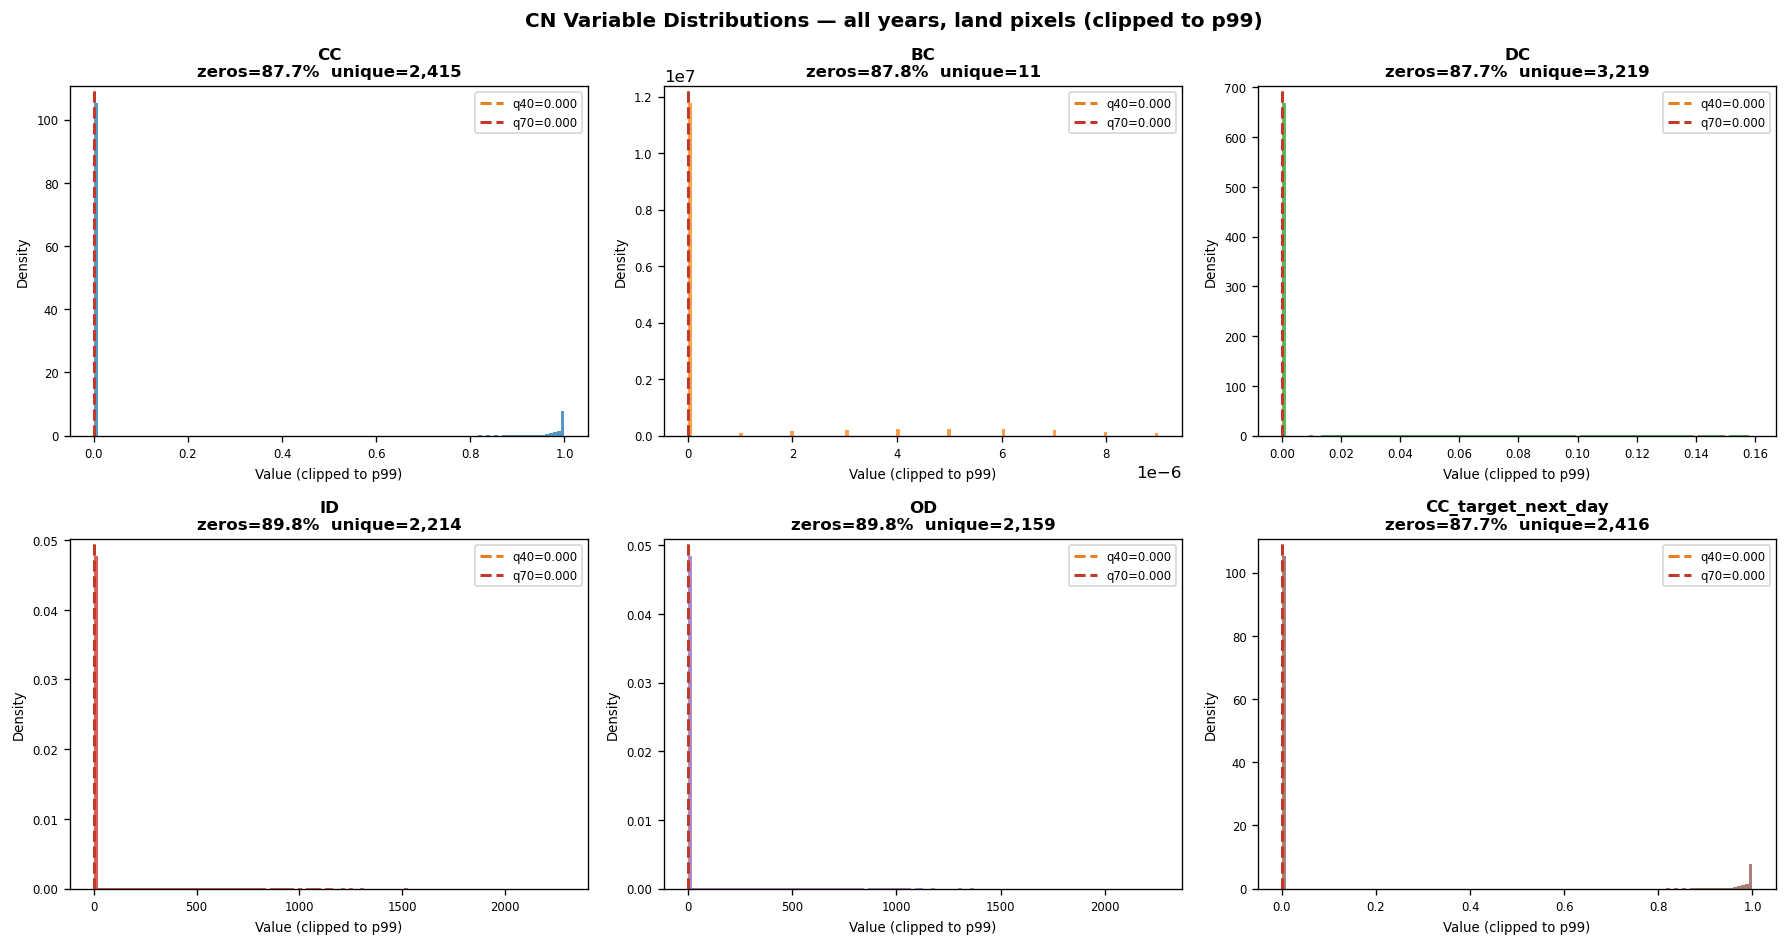

Saved figD1


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(CN_VARS):
    ax   = axes[i]
    vals = dist_data[var]
    p99  = np.percentile(vals, 99)

    ax.hist(vals[vals <= p99], bins=120, color=plt.cm.tab10(i),
            alpha=0.75, edgecolor="none", density=True)

    for q_val, q_label, col in [
        (np.quantile(vals, 0.40), "q40", "#e67e22"),
        (np.quantile(vals, 0.70), "q70", "#c0392b"),
    ]:
        ax.axvline(q_val, color=col, linewidth=1.8, linestyle="--",
                   label=f"{q_label}={q_val:.3f}")

    r = stats_df[stats_df.variable == var].iloc[0]
    ax.set_title(f"{var}\n"
                 f"zeros={r.frac_zero*100:.1f}%  unique={int(r.n_unique):,}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Value (clipped to p99)", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

fig.suptitle("CN Variable Distributions — all years, land pixels (clipped to p99)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "figD1_cn_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved figD1")


### Fig D2 — Zero-inflation comparison

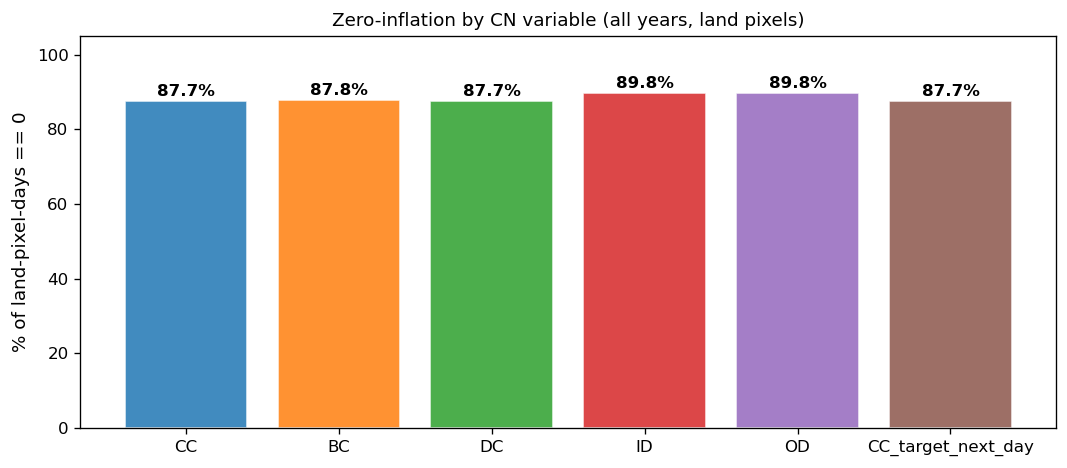

Saved figD2


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
frac_z  = stats_df["frac_zero"].values * 100
colors  = [plt.cm.tab10(i) for i in range(len(CN_VARS))]
bars    = ax.bar(stats_df["variable"], frac_z, color=colors, alpha=0.85, edgecolor="white")

for bar, val in zip(bars, frac_z):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("% of land-pixel-days == 0", fontsize=11)
ax.set_title("Zero-inflation by CN variable (all years, land pixels)", fontsize=11)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "figD2_zero_inflation.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved figD2")


---
## Part 2 — Monthly Mean Maps (June / July / August)

For each CN variable: mean spatial map separately for June, July, August  
averaged across all years 1990–2020.

This shows the **cumulative seasonal pattern** — where network activity concentrates  
during each month of summer, revealing how heatwave network structure evolves  
from early season (June) to peak (July/August).


  CC...


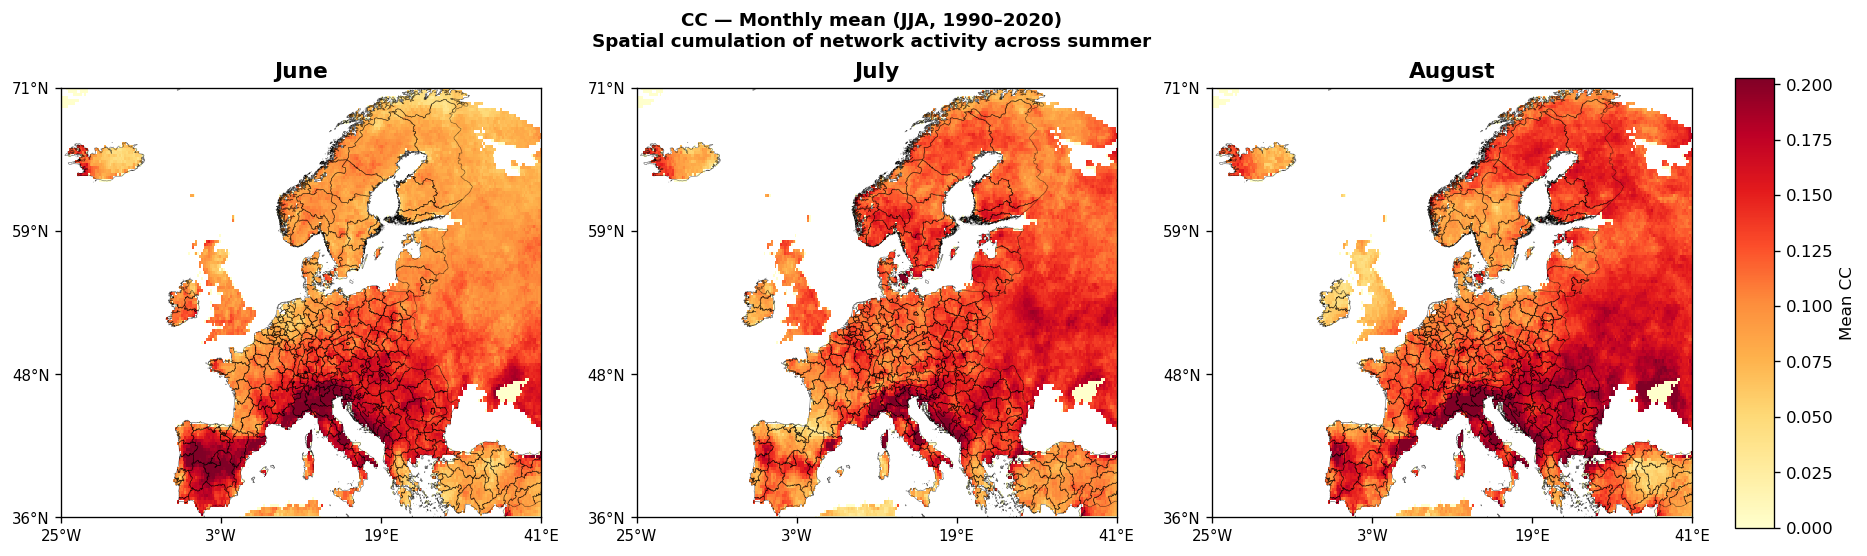

    Saved cn_analysis_outputs/figM_CC_monthly.png
  BC...


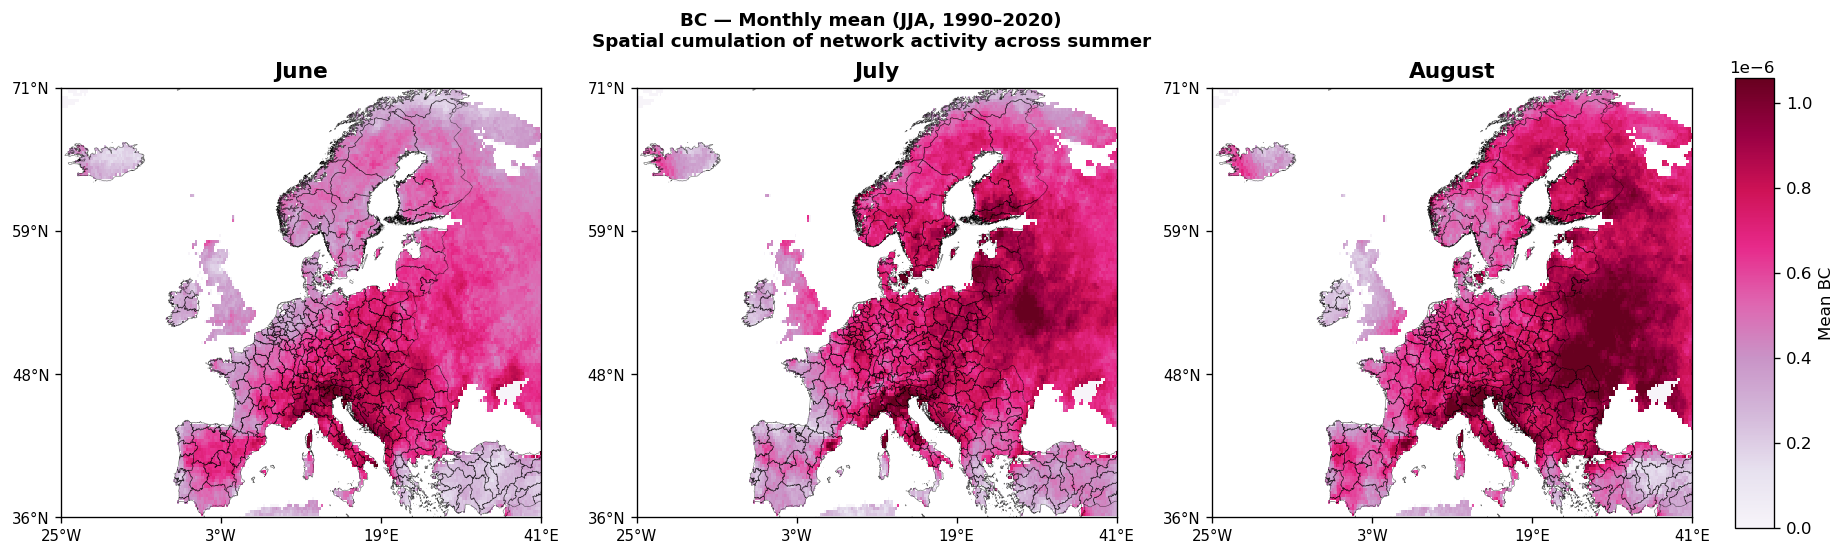

    Saved cn_analysis_outputs/figM_BC_monthly.png
  DC...


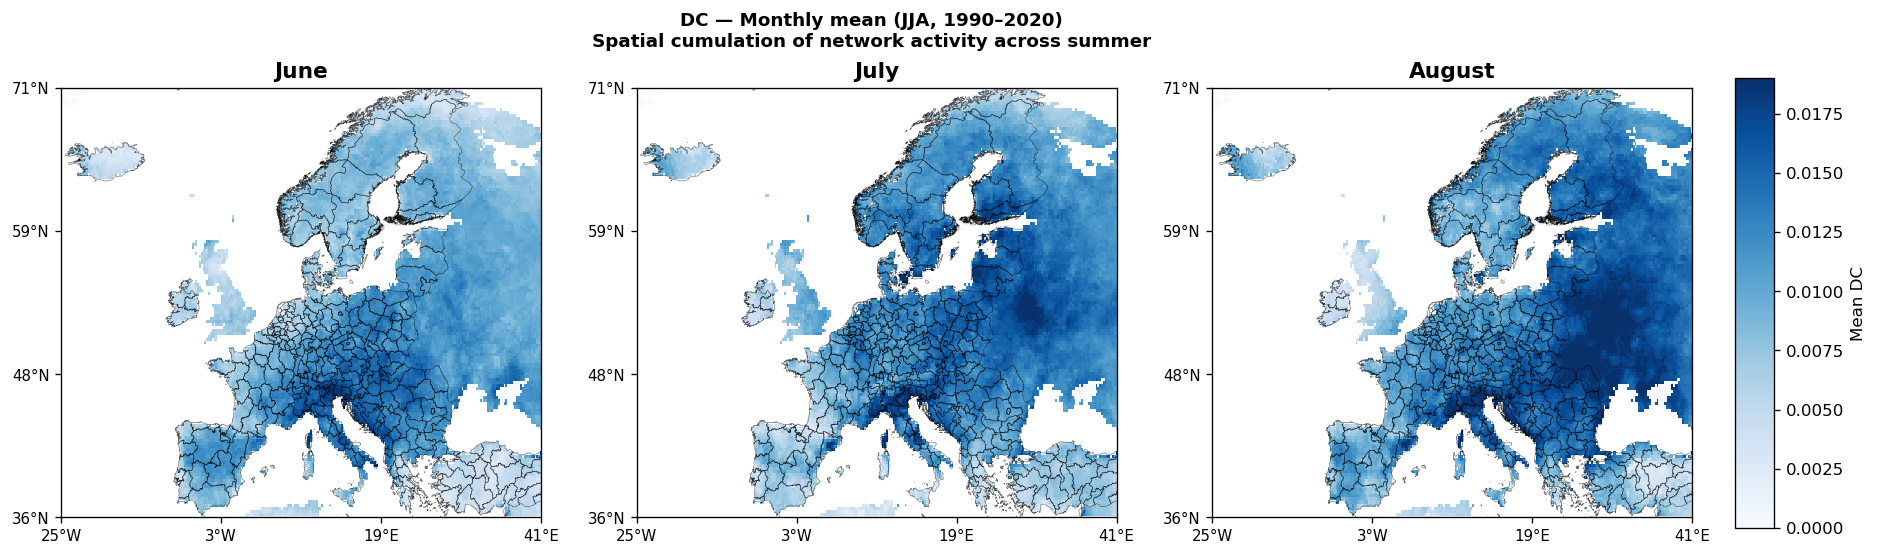

    Saved cn_analysis_outputs/figM_DC_monthly.png
  ID...


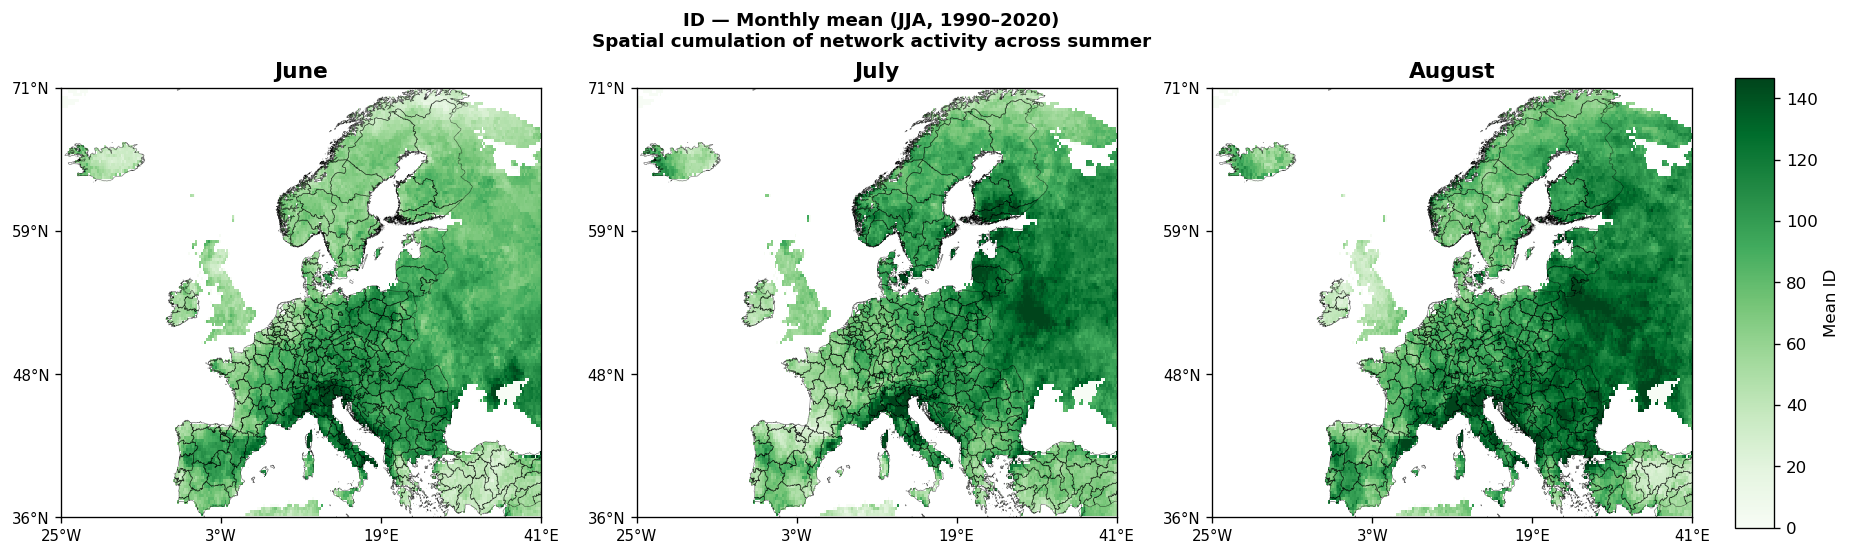

    Saved cn_analysis_outputs/figM_ID_monthly.png
  OD...


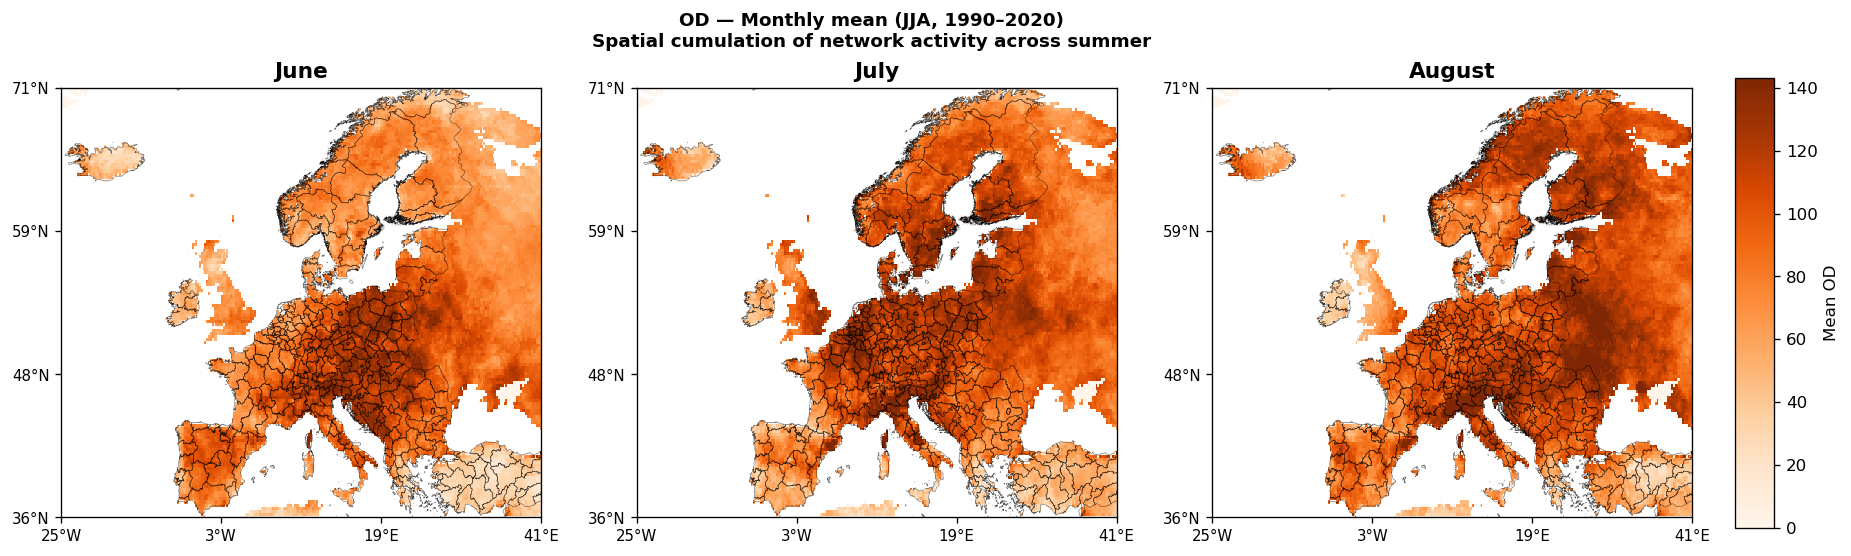

    Saved cn_analysis_outputs/figM_OD_monthly.png
  CC_target_next_day...


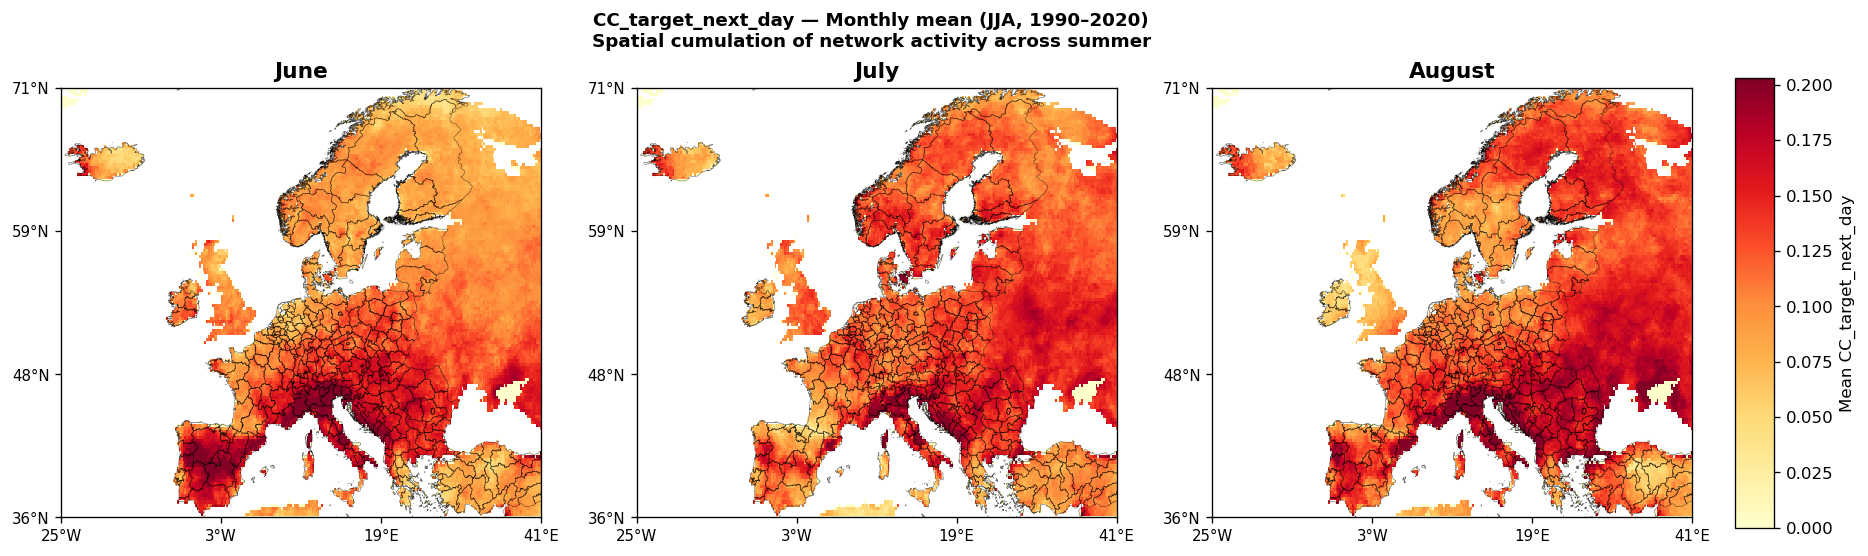

    Saved cn_analysis_outputs/figM_CC_target_next_day_monthly.png


In [9]:
for var in CN_VARS:
    print(f"  {var}...")
    arr = ds[var].values   # (T, lat, lon) south-first

    monthly_means = {}
    for m in MONTHS:
        mask_m = (times.month == m)
        mean_m = np.nanmean(arr[mask_m], axis=0)
        mean_m[~land_mask_sf] = np.nan
        monthly_means[m] = mean_m[::-1, :]   # flip to N-first

    all_vals = np.concatenate([v[~np.isnan(v)].ravel() for v in monthly_means.values()])
    vmin = float(np.nanpercentile(all_vals, 2))
    vmax = float(np.nanpercentile(all_vals, 98))
    cmap = CMAPS.get(var, "viridis")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for col, m in enumerate(MONTHS):
        ax = axes[col]
        pc = ax.pcolormesh(LON2D, LAT2D, monthly_means[m],
                           cmap=cmap, vmin=vmin, vmax=vmax,
                           shading="nearest", zorder=1)
        nuts_eu.boundary.plot(ax=ax, linewidth=0.35,
                              color="black", alpha=0.55, zorder=2)
        setup_ax(ax)

        ax.set_xticks(np.linspace(lons.min(), lons.max(), 4))
        ax.set_xticklabels(
    [f"{v:.0f}°E" if v >= 0 else f"{abs(v):.0f}°W"
     for v in np.linspace(lons.min(), lons.max(), 4)], fontsize=9)
        ax.set_yticks(np.linspace(lats.min(), lats.max(), 4))
        ax.set_yticklabels([f"{v:.0f}°N"
    for v in np.linspace(lats.min(), lats.max(), 4)], fontsize=9)

        vals_m = monthly_means[m][~np.isnan(monthly_means[m])].ravel()
        frac_nz = (vals_m > 0).mean()
        ax.set_title(f"{MONTH_NAMES[m]}", fontsize=13, fontweight="bold")

    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.90, 0.12, 0.018, 0.75])
    sm = plt.cm.ScalarMappable(cmap=cmap,
                               norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label=f"Mean {var}")

    fig.suptitle(f"{var} — Monthly mean (JJA, 1990–2020)\n"
                 f"Spatial cumulation of network activity across summer",
                 fontsize=11, fontweight="bold")

    path = os.path.join(OUT_DIR, f"figM_{var}_monthly.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"    Saved {path}")


### Fig M7 — All variables, August (combined overview)

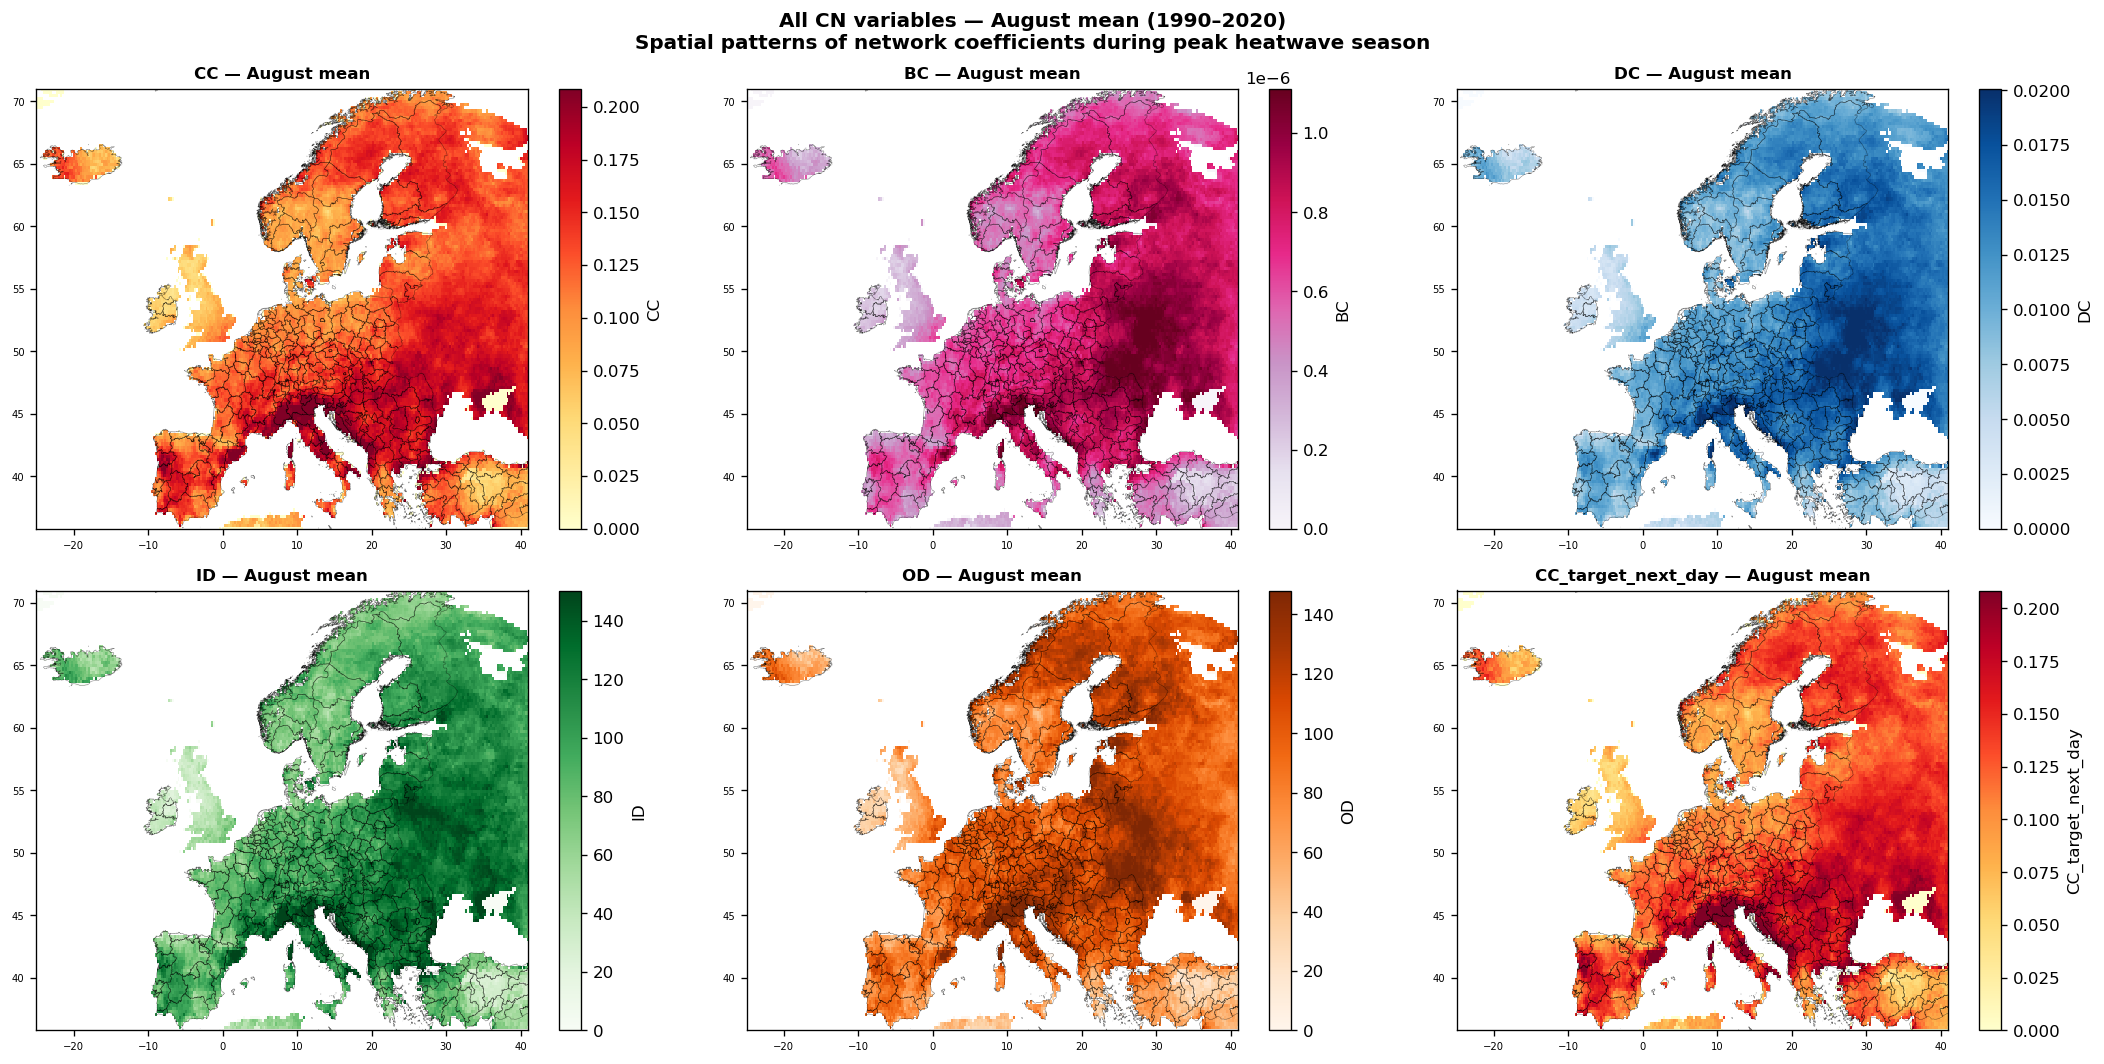

Saved cn_analysis_outputs/figM_ALL_august.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, var in enumerate(CN_VARS):
    ax  = axes[i]
    arr = ds[var].values
    mean_aug = np.nanmean(arr[times.month == 8], axis=0)
    mean_aug[~land_mask_sf] = np.nan
    mean_aug_nf = mean_aug[::-1, :]

    vals = mean_aug_nf[~np.isnan(mean_aug_nf)].ravel()
    vmin = float(np.nanpercentile(vals, 2))
    vmax = float(np.nanpercentile(vals, 98))
    cmap = CMAPS.get(var, "viridis")

    pc = ax.pcolormesh(LON2D, LAT2D, mean_aug_nf,
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       shading="nearest", zorder=1)
    nuts_eu.boundary.plot(ax=ax, linewidth=0.3,
                          color="black", alpha=0.5, zorder=2)
    plt.colorbar(pc, ax=ax, fraction=0.04, label=var)
    setup_ax(ax)
    ax.set_title(f"{var} — August mean", fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=6)

fig.suptitle("All CN variables — August mean (1990–2020)\n"
             "Spatial patterns of network coefficients during peak heatwave season",
             fontsize=12, fontweight="bold")
plt.tight_layout()
path = os.path.join(OUT_DIR, "figM_ALL_august.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {path}")


---
## Cleanup

In [11]:
ds.close()
print(f"All outputs saved to: {OUT_DIR}/")
print("Done.")


All outputs saved to: cn_analysis_outputs/
Done.


---
## Part 3 — Peak Heatwave Cluster Tracking Across Years (1990–2020)

For each year, find the day with the largest active-CC area (the "peak day"),
extract the centroid of its largest connected component (LCC), and plot all
31 peak-day centroids on one map.

This is a **climatological context** analysis, not a model validation —
it uses the observed `CC` field directly (not model predictions), and asks:
do peak heatwave clusters tend to recur in similar locations across years,
or do they vary widely?

A GIF animates the peak-day CC field year by year, showing how the
peak cluster's location and shape evolves across the climatological record.


In [ ]:
from scipy.ndimage import label as nd_label
import imageio.v2 as imageio

PEAK_CC_HIGH_Q = 0.70   # same active-cluster threshold as trajectory analysis
PEAK_MIN_SIZE  = 50     # minimum LCC size in pixels

YEARS = list(range(2000, 2021))

def lcc_centroid(mask, min_size=PEAK_MIN_SIZE):
    """Return (row, col) centroid of the largest connected component, or None."""
    if mask.sum() < min_size:
        return None
    labeled, n_feat = nd_label(mask)
    if n_feat == 0:
        return None
    sizes = np.array([(labeled == i).sum() for i in range(1, n_feat + 1)])
    
    largest = np.argmax(sizes) + 1
    if sizes[largest - 1] < min_size:
        return None
    rows, cols = np.where(labeled == largest)
    return rows.mean(), cols.mean()

def rowcol_to_latlon(row, col):
    # row/col index into south-first lat/lon arrays
    return float(lats[int(round(row))]), float(lons[int(round(col))])


### Compute the active-CC threshold (q70) from full climatology

In [30]:
cc_full = ds["CC"].values  # (T, lat, lon) south-first
cc_land_vals = cc_full[:, land_mask_sf].ravel()
cc_land_vals = cc_land_vals[~np.isnan(cc_land_vals)]
cc_land_vals = cc_land_vals[cc_land_vals >= 0]

cc_thresh_high = np.quantile(cc_land_vals, PEAK_CC_HIGH_Q)
print(f"CC active threshold (q{int(PEAK_CC_HIGH_Q*100)}): {cc_thresh_high:.4f}")


CC active threshold (q70): 0.0000


In [31]:
cc_nonzero = cc_land_vals[cc_land_vals > 0]
cc_thresh_high = np.quantile(cc_nonzero, PEAK_CC_HIGH_Q)
print(f"CC active threshold (q{int(PEAK_CC_HIGH_Q*100)} of non-zero values): {cc_thresh_high:.4f}")

CC active threshold (q70 of non-zero values): 0.9992


### Find peak day and LCC centroid for each year

In [32]:
peak_records = []

for year in YEARS:
    mask_year = (times.year == year)
    cc_year = cc_full[mask_year]              # (n_days, lat, lon)
    dates_year = times[mask_year]

    # Active mask per day (land only)
    active_year = (cc_year >= cc_thresh_high)
    active_year[:, ~land_mask_sf] = False

    # Active area per day -> find peak day
    active_area = active_year.sum(axis=(1, 2))
    if active_area.max() == 0:
        print(f"  {year}: no active days found, skipping")
        continue
    peak_idx = int(np.argmax(active_area))
    peak_date = dates_year[peak_idx]

    centroid = lcc_centroid(active_year[peak_idx])
    if centroid is None:
        print(f"  {year}: peak day {peak_date.date()} has no LCC >= {PEAK_MIN_SIZE}px, skipping")
        continue

    lat_c, lon_c = rowcol_to_latlon(*centroid)
    peak_records.append({
        "year": year,
        "peak_date": peak_date,
        "active_area_pixels": int(active_area[peak_idx]),
        "centroid_lat": lat_c,
        "centroid_lon": lon_c,
        "cc_field": cc_year[peak_idx].copy(),   # store for GIF
    })
    print(f"  {year}: peak {peak_date.date()}  "
          f"area={int(active_area[peak_idx]):5d}px  "
          f"centroid=({lat_c:.2f}N, {lon_c:.2f}E)")

peak_df = pd.DataFrame([{k:v for k,v in r.items() if k != 'cc_field'} for r in peak_records])
peak_df.to_csv(os.path.join(OUT_DIR, "peak_cluster_centroids.csv"), index=False)
peak_df


TypeError: sort() got an unexpected keyword argument 'ascending'

### Fig P1 — All peak-day centroids, 1990–2020

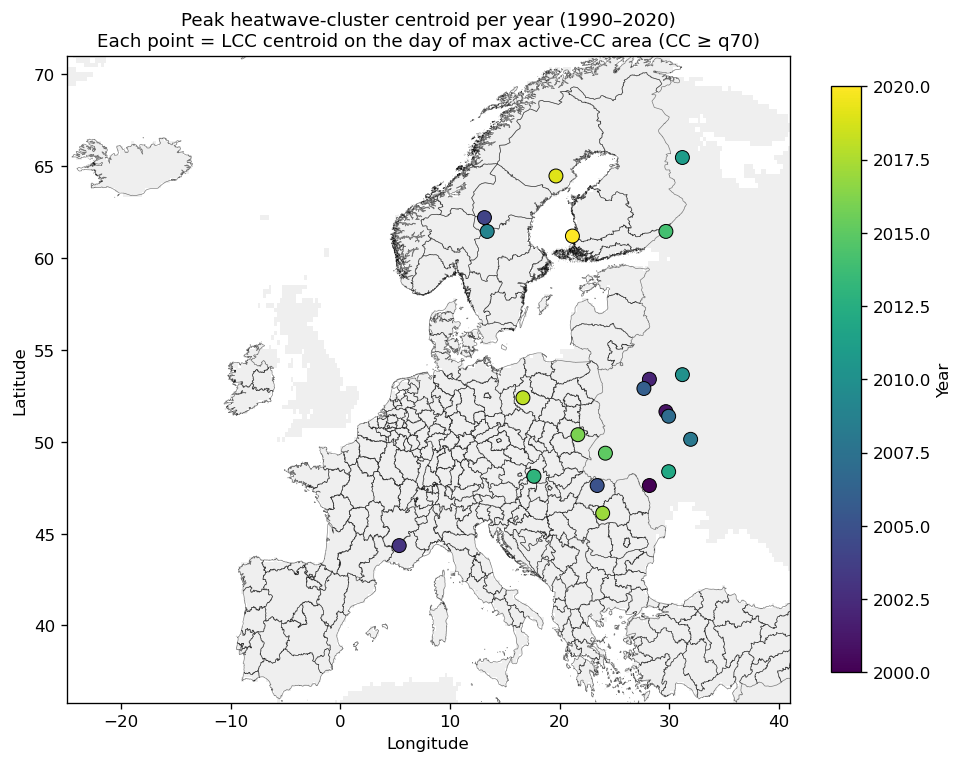

Saved cn_analysis_outputs/figP1_peak_centroids_all_years.png


In [28]:
fig, ax = plt.subplots(figsize=(9, 7))

# Light land background
bg = np.where(land_mask_nf, 0.5, np.nan)
ax.pcolormesh(LON2D, LAT2D, bg, cmap="Greys", vmin=0, vmax=1,
              shading="nearest", alpha=0.15, zorder=1)
nuts_eu.boundary.plot(ax=ax, linewidth=0.4, color="black", alpha=0.5, zorder=2)

lats_pts = peak_df["centroid_lat"].values
lons_pts = peak_df["centroid_lon"].values
years_pts = peak_df["year"].values

sc = ax.scatter(lons_pts, lats_pts, c=years_pts, cmap="viridis",
                s=70, edgecolors="black", linewidths=0.6, zorder=5)
plt.colorbar(sc, ax=ax, fraction=0.035, label="Year")

setup_ax(ax)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Peak heatwave-cluster centroid per year (1990–2020)\n"
             f"Each point = LCC centroid on the day of max active-CC area (CC ≥ q{int(PEAK_CC_HIGH_Q*100)})",
             fontsize=11)

path = os.path.join(OUT_DIR, "figP1_peak_centroids_all_years.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {path}")


### Fig P2 — 2D density of peak centroids

If peak clusters recur in similar locations across years, this should show
concentrated "hot spots" rather than a uniform spread.


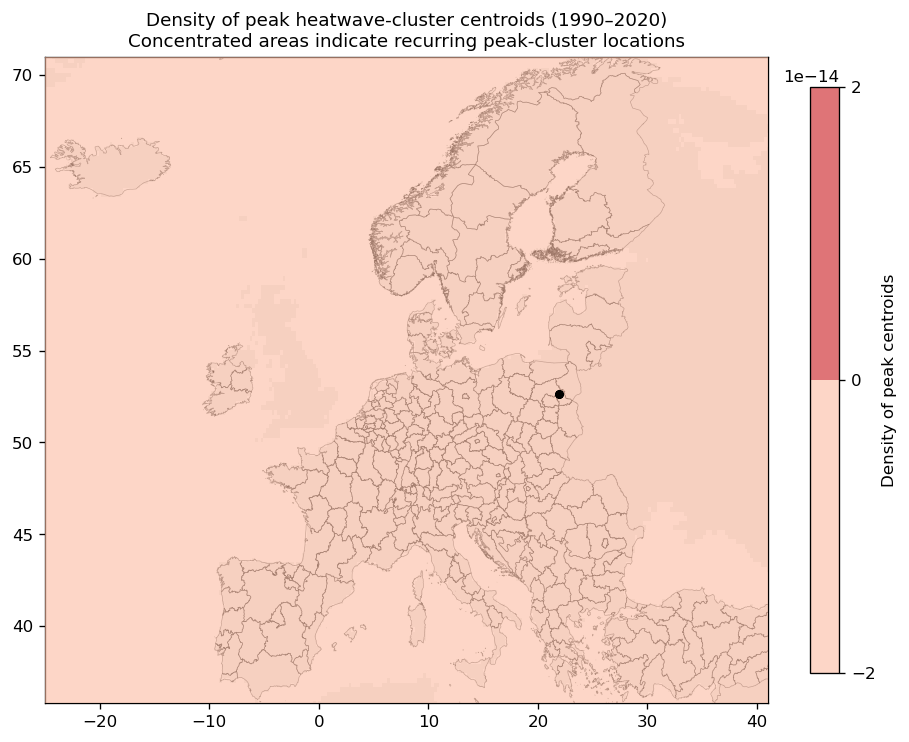

Saved cn_analysis_outputs/figP2_peak_centroid_density.png


In [25]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 7))

bg = np.where(land_mask_nf, 0.5, np.nan)
ax.pcolormesh(LON2D, LAT2D, bg, cmap="Greys", vmin=0, vmax=1,
              shading="nearest", alpha=0.15, zorder=1)
nuts_eu.boundary.plot(ax=ax, linewidth=0.4, color="black", alpha=0.5, zorder=2)

xy = np.vstack([lons_pts, lats_pts])
kde = gaussian_kde(xy)

xgrid = np.linspace(lons.min(), lons.max(), 200)
ygrid = np.linspace(lats.min(), lats.max(), 200)
XX, YY = np.meshgrid(xgrid, ygrid)
ZZ = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)

cf = ax.contourf(XX, YY, ZZ, levels=12, cmap="Reds", alpha=0.6, zorder=3)
ax.scatter(lons_pts, lats_pts, c="black", s=15, zorder=5, alpha=0.6)
plt.colorbar(cf, ax=ax, fraction=0.035, label="Density of peak centroids")

setup_ax(ax)
ax.set_title("Density of peak heatwave-cluster centroids (1990–2020)\n"
             "Concentrated areas indicate recurring peak-cluster locations",
             fontsize=11)

path = os.path.join(OUT_DIR, "figP2_peak_centroid_density.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {path}")


### Animated GIF — peak-day CC field, year by year

One frame per year showing the CC field on its peak day, with the LCC
centroid marked. Frames are ordered 1990 → 2020.


In [ ]:
gif_dir = os.path.join(OUT_DIR, "peak_frames")
os.makedirs(gif_dir, exist_ok=True)

vmax_global = max(r["cc_field"][land_mask_sf].max() for r in peak_records)

frame_paths = []
for r in peak_records:
    fig, ax = plt.subplots(figsize=(7, 6))

    cc_plot = np.where(land_mask_sf, r["cc_field"], np.nan)[::-1, :]  # N-first
    pc = ax.pcolormesh(LON2D, LAT2D, cc_plot, cmap="YlOrRd",
                       vmin=0, vmax=vmax_global, shading="nearest", zorder=1)
    nuts_eu.boundary.plot(ax=ax, linewidth=0.4, color="black", alpha=0.5, zorder=2)

    ax.plot(r["centroid_lon"], r["centroid_lat"], "*", color="cyan",
            markersize=18, markeredgecolor="black", markeredgewidth=1, zorder=5)

    plt.colorbar(pc, ax=ax, fraction=0.04, label="CC")
    setup_ax(ax)
    ax.set_title(f"{r['year']} — peak day {r['peak_date'].date()}\n"
                 f"Active area: {r['active_area_pixels']} px", fontsize=11)

    frame_path = os.path.join(gif_dir, f"frame_{r['year']}.png")
    plt.savefig(frame_path, dpi=100, bbox_inches="tight")
    plt.close()
    frame_paths.append(frame_path)

# Assemble GIF
gif_path = os.path.join(OUT_DIR, "peak_clusters_1990_2020.gif")
images = [imageio.imread(p) for p in frame_paths]
imageio.mimsave(gif_path, images, duration=0.6, loop=0)
print(f"Saved GIF: {gif_path}  ({len(images)} frames)")
